## Visualization Tutorial: HE_mapping (H&E image mapping)

This visualization tutorial is for the **HE_mapping** package.  
All visualizations are based on **(1) predicted spatial coordinates + predicted cell types** and **(2) the matching AnnData output** produced by the H&E mapping pipeline.

CytoBulk H&E mapping results can be obtained in **two ways**:
1) use the provided reference outputs under `result_data/`, or  
2) generate your own outputs by running the `he_mapping` pipeline (see `HE_mapping.md` / Docker/Conda tutorial).

---

Download the `HE_mapping` package

Download the folder **`HE_mapping/`** from **`XXXX`**.

Folder structure (as provided):

- `HE_mapping/`
  - `input/`
    - `TCGA-37-4132.svs` *(H&E whole-slide image)*
    - `HTAN_MSK.h5ad` *(single-cell reference, scRNA AnnData)*
    - `lrpairs.csv` *(ligand–receptor pairs table)*
  - `result_data/`
    - `combinded_cent.txt` *(reference: predicted coordinates + predicted cell type)*
    - `TCGA-37-4132_sub_matching_adata.h5ad` *(reference: mapping output AnnData; used for downstream analysis/plots)*

> Your own run outputs will be under `${OUT_DIR}/demo/` (mapping outputs) and `${OUT_DIR}/demo_split_test/` (tiles), consistent with `HE_mapping.md`.



In [4]:
def plot_he_cell_type(data):
    """
    Display a scatter plot of cell locations colored by cell type.

    Parameters
    ----------
    data : pandas.DataFrame
        Must contain columns:
        - 'cell_type': cell type label for each cell
        - 'x': x-coordinate
        - 'y': y-coordinate

    Notes
    -----
    - Uses predefined colors for common cell types; unknown types default to black.
    - Inverts the y-axis to match typical spatial coordinate conventions.
    - Does not save any files; only displays the figure.
    """
    import matplotlib.pyplot as plt

    # Get unique cell types present in the input data
    categories = data["cell_type"].unique()

    # Predefined color map; cell types not listed here will be colored black
    colors = {
        "Epithelial Cells": "#A52A2A",   # brown
        "Neutrophils": "#0000B8",        # blue
        "Plasma Cells": "#0D98BA",       # cyan
        "Connective Tissue": "#FFCC33",  # yellow
        "Lymphocytes": "#B284BE",        # purple

    }

    plt.figure(figsize=(4, 4))

    # Plot each cell type as a separate scatter layer (for legend clarity)
    for category in categories:
        subset = data[data["cell_type"] == category]
        plt.scatter(
            subset["x"],
            subset["y"],
            label=category,
            color=colors.get(category, "black"),
            s=5,
            alpha=0.8,
        )

    # Add a compact legend
    plt.legend(
        loc="upper right",
        title="Cell Types",
        fontsize=8,
        title_fontsize=10,
        markerscale=1.5,
    )

    # Hide axes and invert y for spatial-style orientation
    ax = plt.gca()
    ax.axis("off")
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

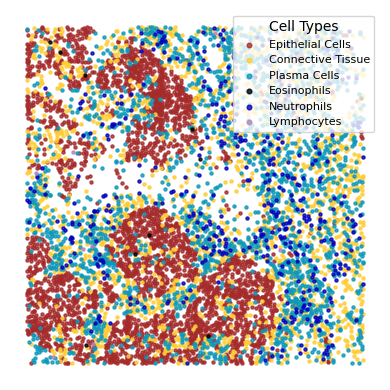

In [5]:
import pandas as pd
# NOTE: Please change the file paths below to your own local paths before running.
cell_coordinates = pd.read_csv(
    r"C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\HE_mapping\result_data\combinded_cent.txt",
    sep="\t",
    header=None,
)

cell_coordinates.columns = ["data_set", "x", "y", "cell_type"]

plot_he_cell_type(
    cell_coordinates)

### COMMOT analysis visualization
For COMMOT analysis visualization, please make sure you have installed the **`commot`** package in advance.

In [8]:
import scanpy as sc
adata = sc.read_h5ad(r"C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\HE_mapping\result_data\commot_result_adata.h5ad")

In [9]:
pathway_names = []
for x in adata.obsm['commot-cellchat-sum-receiver'].columns:
    if len(x.split('-')) == 2:
       pathway_names.append(x.replace('r-', ''))


In [14]:
from typing import Optional, Union
import matplotlib as mpl
from sklearn.neighbors import NearestNeighbors
from scipy.stats import norm
import numpy as np
import anndata
import matplotlib.pyplot as plt
def plot_cell_communication(
    adata: anndata.AnnData,
    database_name: str = None,
    pathway_name: str = None,
    lr_pair = None,
    keys = None,
    plot_method: str = "cell",
    background: str = "summary",
    background_legend: bool=False,
    clustering: str = None,
    summary: str = "sender",
    cmap: str = "coolwarm",
    cluster_cmap: dict = None,
    cluster_alpha: float = 1.0,
    pos_idx: np.ndarray = np.array([0,1],int),
    ndsize: float = 1,
    scale: float = 1.0,
    normalize_v: bool = False,
    normalize_v_quantile: float = 0.95,
    arrow_color: str = "#333333",
    grid_density: float = 1.0,
    grid_knn: int = None,
    grid_scale: float = 1.0,
    grid_thresh: float = 1.0,
    grid_width: float = 0.005,
    stream_density: float = 1.0,
    stream_linewidth: float = 1,
    stream_cutoff_perc: float = 5,
    filename: str = None,
    ax: Optional[mpl.axes.Axes] = None
):
    """
    Plot spatial directions of cell-cell communication.

    .. image:: cell_communication.png
        :width: 500pt

    The cell-cell communication should have been computed by the function :func:`commot.tl.spatial_communication`.
    The cell-cell communication direction should have been computed by the function :func:`commot.tl.communication_direction`.

    Parameters
    ----------
    adata
        The data matrix of shape ``n_obs`` × ``n_var``.
        Rows correspond to cells or positions and columns to genes.
    database_name
        Name of the ligand-receptor interaction database.
    pathway_name
        Name of the signaling pathway to be plotted. Will be used only when ``lr_pair`` and ``keys`` are None.
        If none of ``pathway_name``, ``lr_pair``, and ``keys`` are given, the total signaling through all pairs will be plotted.
    lr_pair
        A tuple of ligand name and receptor name. If given, ``pathway_name`` will be ignored. Will be ignored if ``keys`` is given.
    keys
        A list of keys for example 'ligA-recA' for a LR pair or 'pathwayX' for a signaling pathway 'pathwayX'.
        If given, pathway_name and lr_pair will be ignored.
        If more than one is given, the average will be plotted.
    plot_method
        'cell' plot vectors on individual cells.
        'grid' plot interpolated vectors on regular grids.
        'stream' streamline plot.
    background
        'summary': scatter plot with color representing total sent or received signal.
        'image': the image in Visium data.
        'cluster': scatter plot with color representing cell clusters.
    background_legend
        Whether to include the background legend when background is set to `summary` or `cluster`.
    clustering
        The key for clustering result. Needed if background is set to `cluster`.
        For example, if ``clustering=='leiden'``, the clustering result should be available in ``.obs['leiden']``.
    summary
        If background is set to 'summary', the numerical value to plot for background.
        'sender': node color represents sender weight.
        'receiver': node color represents receiver weight.
    cmap
        matplotlib colormap name for node summary if numerical (background set to 'summary'), e.g., 'coolwarm'.
        plotly colormap name for node color if summary is (background set to 'cluster'). e.g., 'Alphabet'.
    cluster_cmap
        A dictionary that maps cluster names to colors when setting background to 'cluster'. If given, ``cmap`` will be ignored.
    pos_idx
        The coordinates to use for plotting (2D plot).
    ndsize
        The node size of the spots.
    scale
        The scale parameter passed to the matplotlib quiver function :func:`matplotlib.pyplot.quiver` for vector field plots.
        The smaller the value, the longer the arrows.
    normalize_v
        Whether the normalize the vector field to uniform lengths to highlight the directions without showing magnitudes.
    normalize_v_quantile
        The vector length quantile to use to normalize the vector field.
    arrow_color
        The color of the arrows.
    grid_density
        The density of grid if ``plot_method=='grid'``.
    grid_knn
        If ``plot_method=='grid'``, the number of nearest neighbors to interpolate the signaling directions from spots to grid points.
    grid_scale
        The scale parameter (relative to grid size) for the kernel function of mapping directions of spots to grid points.
    grid_thresh
        The threshold of interpolation weights determining whether to include a grid point. A smaller value gives a tighter cover of the tissue by the grid points.
    grid_width
        The value passed to the ``width`` parameter of the function :func:`matplotlib.pyplot.quiver` when ``plot_method=='grid'``.
    stream_density
        The density of stream lines passed to the ``density`` parameter of the function :func:`matplotlib.pyplot.streamplot` when ``plot_method=='stream'``.
    stream_linewidth
        The width of stream lines passed to the ``linewidth`` parameter of the function :func:`matplotlib.pyplot.streamplot` when ``plot_method=='stream'``.
    stream_cutoff_perc
        The quantile cutoff to ignore the weak vectors. Default to 5 that the vectors shorter than the 5% quantile will not be plotted.
    filename
        If given, save to the filename. For example 'ccc_direction.pdf'.
    ax
        An existing matplotlib ax (`matplotlib.axis.Axis`).

    Returns
    -------
    ax : matplotlib.axis.Axis
        The matplotlib ax object of the plot.

    """

    if not keys is None:
        ncell = adata.shape[0]
        V = np.zeros([ncell, 2], float)
        signal_sum = np.zeros([ncell], float)
        for key in keys:
            if summary == 'sender':
                V = V + adata.obsm['commot_sender_vf-'+database_name+'-'+key][:,pos_idx]
                signal_sum = signal_sum + adata.obsm['commot-'+database_name+"-sum-sender"]['s-'+key]
            elif summary == 'receiver':
                V = V + adata.obsm['commot_receiver_vf-'+database_name+'-'+key][:,pos_idx]
                signal_sum = signal_sum + adata.obsm['commot-'+database_name+"-sum-receiver"]['r-'+key]
        V = V / float( len( keys ) )
        signal_sum = signal_sum / float( len( keys ) )
    elif keys is None:
        if not lr_pair is None:
            vf_name = database_name+'-'+lr_pair[0]+'-'+lr_pair[1]
            sum_name = lr_pair[0]+'-'+lr_pair[1]
        elif not pathway_name is None:
            vf_name = database_name+'-'+pathway_name
            sum_name = pathway_name
        else:
            vf_name = database_name+'-total-total'
            sum_name = 'total-total'
        if summary == 'sender':
            V = adata.obsm['commot_sender_vf-'+vf_name][:,pos_idx]
            signal_sum = adata.obsm['commot-'+database_name+"-sum-sender"]['s-'+sum_name]
        elif summary == 'receiver':
            V = adata.obsm['commot_receiver_vf-'+vf_name][:,pos_idx]
            signal_sum = adata.obsm['commot-'+database_name+"-sum-receiver"]['r-'+sum_name]

    if ax is None:
        fig, ax = plt.subplots()
    if normalize_v:
        V = V / np.quantile(np.linalg.norm(V, axis=1), normalize_v_quantile)
    plot_cell_signaling(
        adata.obsm["spatial"][:,pos_idx],
        V,
        signal_sum,
        cmap = cmap,
        cluster_cmap = cluster_cmap,
        cluster_alpha = cluster_alpha,
        plot_method = plot_method,
        background = background,
        clustering = clustering,
        background_legend = background_legend,
        adata = adata,
        summary = summary,
        scale = scale,
        ndsize = ndsize,
        filename = filename,
        arrow_color = arrow_color,
        grid_density = grid_density,
        grid_knn = grid_knn,
        grid_scale = grid_scale,
        grid_thresh = grid_thresh,
        grid_width = grid_width,
        stream_density = stream_density,
        stream_linewidth = stream_linewidth,
        stream_cutoff_perc = stream_cutoff_perc,
        ax = ax,
        # fig = fig,
    )
    return ax

def plot_cell_signaling(X,
    V,
    signal_sum,
    cmap="coolwarm",
    cluster_cmap = None,
    cluster_alpha = None,
    arrow_color="tab:blue",
    plot_method="cell",
    background='summary',
    clustering=None,
    background_legend=False,
    adata=None,
    summary='sender',
    ndsize = 1,
    scale = 1.0,
    grid_density = 1,
    grid_knn = None,
    grid_scale = 1.0,
    grid_thresh = 1.0,
    grid_width = 0.005,
    stream_density = 2.0,
    stream_linewidth = 1,
    stream_cutoff_perc = 5,
    filename=None,
    ax = None,
    fig = None
):
    ndcolor = signal_sum
    ncell = X.shape[0]

    V_cell = V.copy()
    V_cell_sum = np.sum(V_cell, axis=1)
    V_cell[np.where(V_cell_sum==0)[0],:] = np.nan
    if summary == "sender":
        X_vec = X
    elif summary == "receiver":
        X_vec = X - V / scale

    if plot_method == "grid" or plot_method == "stream":
        # Get a rectangular grid
        xl, xr = np.min(X[:,0]), np.max(X[:,0])
        epsilon = 0.02*(xr-xl); xl -= epsilon; xr += epsilon
        yl, yr = np.min(X[:,1]), np.max(X[:,1])
        epsilon = 0.02*(yr-yl); yl -= epsilon; yr += epsilon
        ngrid_x = int(50 * grid_density)
        gridsize = (xr-xl) / float(ngrid_x)
        ngrid_y = int((yr-yl)/gridsize)
        meshgrid = np.meshgrid(np.linspace(xl,xr,ngrid_x), np.linspace(yl,yr,ngrid_y))
        grid_pts = np.concatenate((meshgrid[0].reshape(-1,1), meshgrid[1].reshape(-1,1)), axis=1)

        if grid_knn is None:
            grid_knn = int( X.shape[0] / 50 )
        nn_mdl = NearestNeighbors()
        nn_mdl.fit(X)
        dis, nbs = nn_mdl.kneighbors(grid_pts, n_neighbors=grid_knn)
        w = norm.pdf(x=dis, scale=gridsize * grid_scale)
        w_sum = w.sum(axis=1)

        V_grid = (V[nbs] * w[:,:,None]).sum(axis=1)
        V_grid /= np.maximum(1, w_sum)[:,None]

        if plot_method == "grid":
            grid_thresh *= np.percentile(w_sum, 99) / 100
            grid_pts, V_grid = grid_pts[w_sum > grid_thresh], V_grid[w_sum > grid_thresh]
        elif plot_method == "stream":
            x_grid = np.linspace(xl, xr, ngrid_x)
            y_grid = np.linspace(yl, yr, ngrid_y)
            V_grid = V_grid.T.reshape(2, ngrid_y, ngrid_x)
            vlen = np.sqrt((V_grid ** 2).sum(0))
            grid_thresh = 10 ** (grid_thresh - 6)
            grid_thresh = np.clip(grid_thresh, None, np.max(vlen) * 0.9)
            cutoff = vlen.reshape(V_grid[0].shape) < grid_thresh
            length = np.sum(np.mean(np.abs(V[nbs]),axis=1),axis=1).T
            length = length.reshape(ngrid_y, ngrid_x)
            #cutoff |= length < np.percentile(length, stream_cutoff_perc)
            cutoff |= length < np.percentile(length, stream_cutoff_perc)

            V_grid[0][cutoff] = np.nan

    if cmap == 'Plotly':
        cmap = plotly.colors.qualitative.Plotly
    elif cmap == 'Light24':
        cmap = plotly.colors.qualitative.Light24
    elif cmap == 'Dark24':
        cmap = plotly.colors.qualitative.Dark24
    elif cmap == 'Alphabet':
        cmap = plotly.colors.qualitative.Alphabet

    idx = np.argsort(ndcolor)
    if background == 'summary' or background == 'cluster':
        if not ndsize==0:
            if background == 'summary':
                ax.scatter(X[idx,0], X[idx,1], s=ndsize, c=ndcolor[idx], cmap=cmap, linewidth=0)
            elif background == 'cluster':
                labels = np.array( adata.obs[clustering], str )
                unique_labels = np.sort(list(set(list(labels))))
                for i_label in range(len(unique_labels)):
                    idx = np.where(labels == unique_labels[i_label])[0]
                    if cluster_cmap is None:
                        ax.scatter(X[idx,0], X[idx,1], s=ndsize, c=cmap[i_label], linewidth=0, label=unique_labels[i_label], alpha=cluster_alpha)
                    elif not cluster_cmap is None:
                        ax.scatter(X[idx,0], X[idx,1], s=ndsize, c=cluster_cmap[unique_labels[i_label]], linewidth=0, label=unique_labels[i_label], alpha=cluster_alpha)
                if background_legend:
                    ax.legend(markerscale=2.0, loc=[1.0,0.0])
        if plot_method == "cell":
            ax.quiver(X_vec[:,0], X_vec[:,1], V_cell[:,0], V_cell[:,1], scale=scale, scale_units='x', color=arrow_color)
        elif plot_method == "grid":
            ax.quiver(grid_pts[:,0], grid_pts[:,1], V_grid[:,0], V_grid[:,1], scale=scale, scale_units='x', width=grid_width, color=arrow_color)
        elif plot_method == "stream":
            lengths = np.sqrt((V_grid ** 2).sum(0))
            stream_linewidth *= 2 * lengths / lengths[~np.isnan(lengths)].max()
            ax.streamplot(x_grid, y_grid, V_grid[0], V_grid[1], color=arrow_color, density=stream_density, linewidth=stream_linewidth,minlength=0.05,maxlength=0.25)

    elif background == 'image':
        spatial_mapping = adata.uns.get("spatial", {})
        library_id = list(spatial_mapping.keys())[0]
        spatial_data = spatial_mapping[library_id]
        img = spatial_data['images']['hires']
        sf = spatial_data['scalefactors']['tissue_hires_scalef']
        ax.imshow(img, origin='lower')
        if plot_method == "cell":
            ax.quiver(X_vec[:,0]*sf, X_vec[:,1]*sf, V_cell[:,0]*sf, V_cell[:,1]*sf, scale=scale, scale_units='x', color=arrow_color)
        elif plot_method == "grid":
            ax.quiver(grid_pts[:,0]*sf, grid_pts[:,1]*sf, V_grid[:,0]*sf, V_grid[:,1]*sf, scale=scale, scale_units='x', width=grid_width, color=arrow_color)
        elif plot_method == "stream":
            lengths = np.sqrt((V_grid ** 2).sum(0))
            stream_linewidth *= 2 * lengths / lengths[~np.isnan(lengths)].max()
            ax.streamplot(x_grid*sf, y_grid*sf, V_grid[0]*sf, V_grid[1]*sf, color=arrow_color, density=stream_density, linewidth=stream_linewidth)

    #ax.axis("equal")
    ax.axis("off")
    if not filename is None:
        plt.savefig(filename, dpi=500, bbox_inches = 'tight', transparent=True)


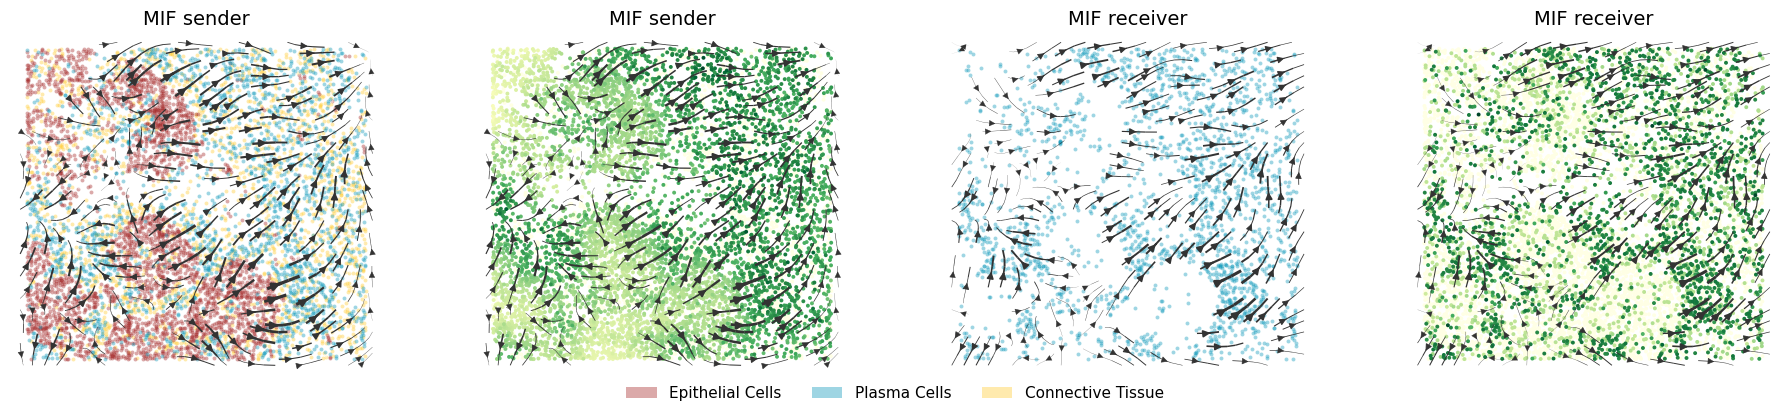

In [15]:
import commot as ct
import matplotlib.pyplot as plt
for pathway_name in ['MIF']:

    fig, axes = plt.subplots(1, 4, figsize=(18, 4)) 
    cluster_alpha = 0.4
    
    # 在绘图前先计算统一的坐标范围
    x_min, x_max = adata.obsm["spatial"][:, 0].min(), adata.obsm["spatial"][:, 0].max()
    y_min, y_max = adata.obsm["spatial"][:, 1].min(), adata.obsm["spatial"][:, 1].max()
    
    # 添加一些边距
    x_margin = (x_max - x_min) * 0.05
    y_margin = (y_max - y_min) * 0.05

    r_palette = {
            "Epithelial Cells": 'white',
            "Neutrophils": 'white',
            "Plasma Cells": "#0D98BA",
            "Connective Tissue": 'white',
            "Lymphocytes": 'white'
    }
    ct.tl.communication_direction(adata, database_name='cellchat', pathway_name=pathway_name, k=15)
    ax = plot_cell_communication(adata, database_name='cellchat', pathway_name=pathway_name, plot_method='stream', background_legend=False,
        scale=0.00003, ndsize=8, grid_density=0.4, summary='receiver', background='cluster', clustering='cell_type', 
        normalize_v = True, normalize_v_quantile=0.995,stream_linewidth=1.2,cluster_cmap=r_palette, cluster_alpha=cluster_alpha, ax=axes[2])
    ax.set_title(f'{pathway_name} receiver', fontsize=14)
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    ax.set_ylim(y_min - y_margin, y_max + y_margin)
    ax.invert_yaxis()
    s_palette = {
            "Epithelial Cells": "#A52A2A",
            "Neutrophils": 'white',
            "Plasma Cells": "#0D98BA",
            "Connective Tissue":  "#FFCC33",
            "Lymphocytes": 'white'
    }
    ax = plot_cell_communication(adata, database_name='cellchat', pathway_name=pathway_name, plot_method='stream', background_legend=False,
        scale=0.00003, ndsize=8, grid_density=0.4, summary='sender', background='cluster', cluster_alpha=cluster_alpha, clustering='cell_type', 
        normalize_v = True, normalize_v_quantile=0.995,stream_linewidth=1.2,cluster_cmap=s_palette, ax=axes[0])
    ax.set_title(f'{pathway_name} sender', fontsize=14)
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    ax.set_ylim(y_min - y_margin, y_max + y_margin)
    ax.invert_yaxis()
    ct.tl.communication_direction(adata, database_name='cellchat', pathway_name=pathway_name, k=15)
    ax = plot_cell_communication(adata, database_name='cellchat', pathway_name=pathway_name, plot_method='stream', background_legend=False,
        scale=0.00003, ndsize=8, grid_density=0.4, summary='receiver', background='summary', clustering='cell_type', 
        normalize_v = True, normalize_v_quantile=0.995,stream_linewidth=1.2,cmap='YlGn', ax=axes[3])
    ax.set_title(f'{pathway_name} receiver', fontsize=14)
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    ax.set_ylim(y_min - y_margin, y_max + y_margin)
    ax.invert_yaxis()
    ax = plot_cell_communication(adata, database_name='cellchat', pathway_name=pathway_name, plot_method='stream', background_legend=False,
        scale=0.00003, ndsize=8, grid_density=0.4, summary='sender', background='summary', clustering='cell_type', 
        normalize_v = True, normalize_v_quantile=0.995,stream_linewidth=1.2,cmap='YlGn', ax=axes[1])
    ax.set_title(f'{pathway_name} sender', fontsize=14)
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    ax.set_ylim(y_min - y_margin, y_max + y_margin)
    ax.invert_yaxis()
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, label=label, alpha=cluster_alpha) 
                       for label, color in s_palette.items() if color != 'white']
    
    fig.legend(handles=legend_elements, loc='lower center', 
               ncol=len(legend_elements), bbox_to_anchor=(0.5, -0.05),
               frameon=False, fontsize=11)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.05, wspace=0.25)
    plt.show()

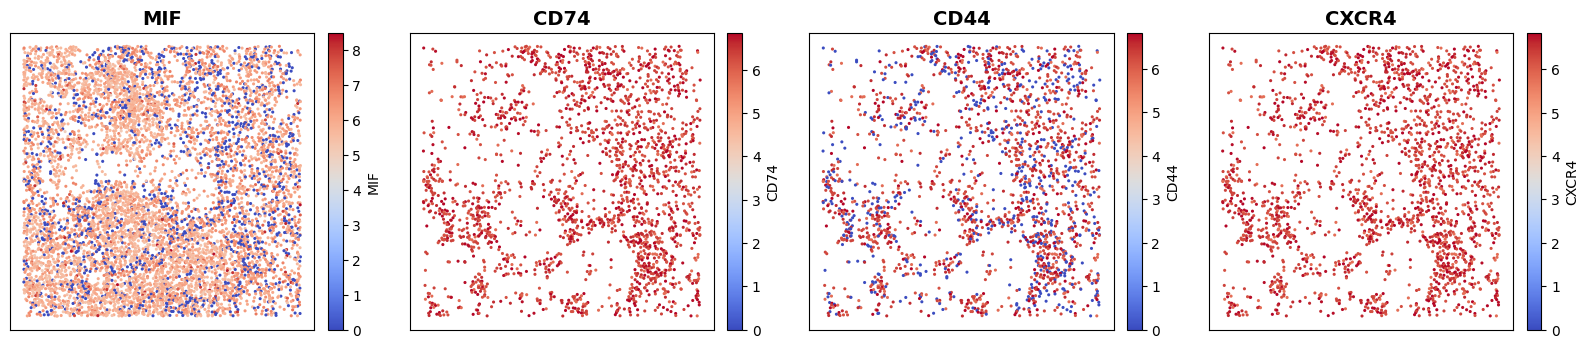

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize

def spatial_plot_multi_selective(df, genes, palette="coolwarm", point_size=5, figsize=(14, 3.5), wspace=0.2):
    """
    Plot multiple spatial gene expressions in subplots.
    First gene (MIF) shows all selected cell types, remaining genes show only Plasma Cells.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns 'x', 'y', 'cell_type', and the genes to plot.
    genes : list of str
        List of column names with expression values.
    palette : str or matplotlib colormap, optional
        Colormap to use (e.g., 'viridis', 'coolwarm').
    point_size : float, optional
        Marker size for each spot.
    figsize : tuple, optional
        Figure size (width, height).
    wspace : float, optional
        Width space between subplots (default: 0.2).
    """
    n_genes = len(genes)
    fig, axes = plt.subplots(1, n_genes, figsize=figsize)
    
    # Ensure axes is always a list
    if n_genes == 1:
        axes = [axes]
    
    for idx, gene in enumerate(genes):
        ax = axes[idx]
        
        if idx == 0:
            df_plot = df[df['cell_type'].isin(['Plasma Cells', 'Connective Tissue', 'Epithelial Cells'])]
        else:
            df_plot = df[df['cell_type'].isin(['Plasma Cells'])]
        
        # Calculate normalization for this gene
        vmax = df_plot[gene].max()
        norm = Normalize(vmin=0, vmax=vmax if vmax > 0 else 1.0)
        
        # Create scatter plot
        sns.scatterplot(
            data=df_plot,
            x="x",
            y="y",
            hue=gene,
            palette=palette,
            hue_norm=norm,
            s=point_size,
            linewidth=0,
            legend=False,
            ax=ax,
        )
        
        # Set labels and ticks
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.invert_yaxis()  # match Visium orientation
        ax.set_title(gene, fontsize=14, fontweight='bold')
        
        # Add colorbar
        sm = plt.cm.ScalarMappable(norm=norm, cmap=palette)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(gene, fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=wspace)  
    plt.show()


receptors = ['CD74', 'CD44', 'CXCR4'] 
genes_to_plot = ['MIF'] + receptors
df = adata[:, ['MIF'] + receptors].to_df()
df['x'] = adata.obsm['spatial'][:,0]
df['y'] = adata.obsm['spatial'][:,1]
df['cell_type'] = adata.obs['cell_type']

spatial_plot_multi_selective(
    df, 
    genes=genes_to_plot, 
    palette='coolwarm', 
    point_size=5,
    figsize=(16, 3.5),
    wspace=0.2
)

---

## Visualization Tutorial: HE_mapping_CID867 (H&E image mapping for CID867)

This visualization tutorial is for the **HE_mapping_CID867** package.  
All visualizations compare **gene-wise expression accuracy** between two methods:
- **Expression-only OT**: optimal transport based on expression similarity alone
- **CytoBulk**: optimal transport combining expression, spatial structure, and ligand-receptor interactions

The results can be obtained in **two ways**:
1) Use the provided reference outputs under `HE_mapping_CID867/result_data/`, or  
2) Generate your own outputs by running the `HE_mapping_CID867` pipeline (see the Conda or Docker tutorial).

---

### Download the `HE_mapping_CID867` package

Download the folder **`HE_mapping_CID867/`** from **`XXXX`**.

Folder structure (as provided):

- `HE_mapping_CID867/`
  - `input/`
    - `cropped_image_3_1.svs` *(input H&E SVS image)*
    - `demo_original_sc_adata.h5ad` *(ground-truth expression AnnData)*
    - `lrpairs.csv` *(ligand–receptor pairs table)*
    - `combinded_cent.txt` *(filtered segmentation data)*
    - `5/`, `10/`, `15/`, `20/` *(anchor expression files at different gene-retention percentages)*
  - `result_data/`
    - `5/`
      - `demo_matching_adata_5_cytobulk.h5ad` *(CytoBulk mapping result using 5% anchor genes)*
      - `demo_matching_adata_5_expression.h5ad` *(Expression-only OT result using 5% anchor genes)*
    - `10/`, `15/`, `20/` *(reference results for other anchor gene percentages)*

> This tutorial uses the **5% anchor genes** results as an example.

---

### Gene-wise Expression Comparison: Pearson Correlation and MSE

This visualization compares the gene-wise prediction accuracy between **Expression-only OT** and **CytoBulk** methods by:
1. Matching predicted cells to ground-truth cells by spatial coordinates
2. Computing **Pearson correlation** and **MSE** for each gene across all matched cells
3. Visualizing the distribution of these metrics and performing statistical tests


Loading data...
Number of common genes: 343
Number of common genes: 343

Pearson correlation statistical test (Mann-Whitney U test):
Statistic: 9387.0000, P-value: 6.69e-81

MSE statistical test (Mann-Whitney U test):
Statistic: 84563.0000, P-value: 3.49e-23


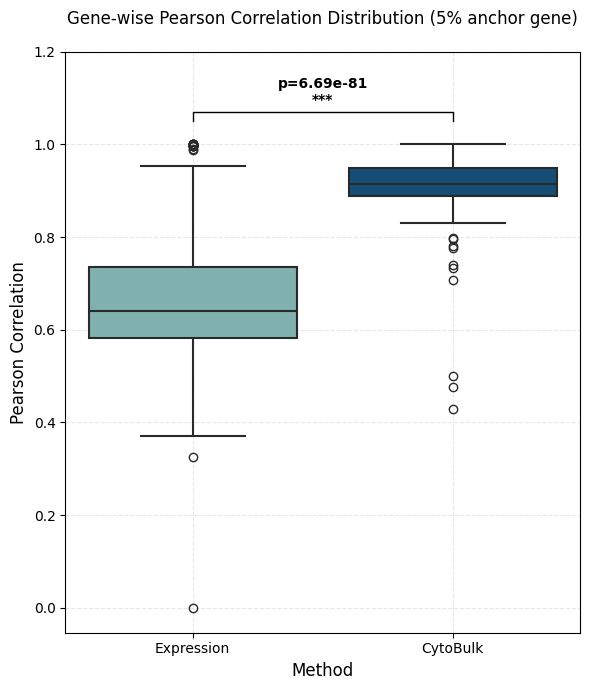

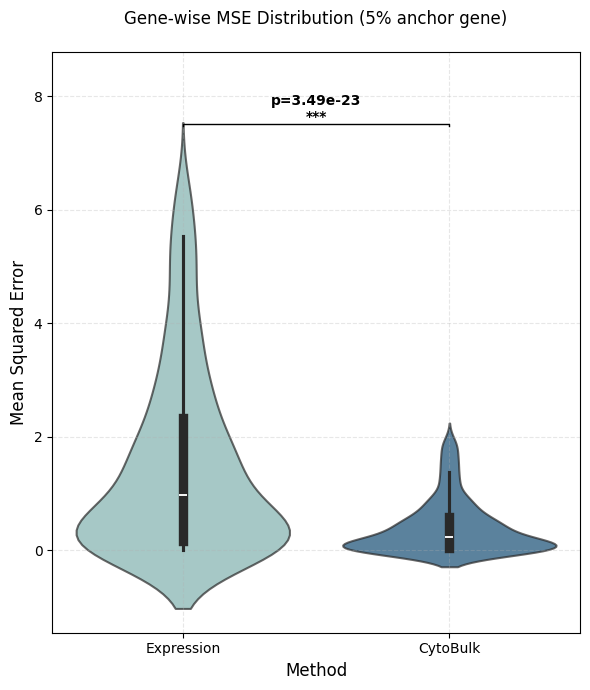


Statistical Summary (5% Anchor Genes)

Number of common genes: 343
Number of matched cell pairs: 10552

------------------------------------------------------------
Pearson Correlation:
------------------------------------------------------------
Method          Mean       Median     Std       
Expression      0.6692     0.6396     0.1375    
CytoBulk        0.9147     0.9157     0.0637    

Mann-Whitney U test: Statistic=9387.0000, p-value=6.69e-81

------------------------------------------------------------
Mean Squared Error (MSE):
------------------------------------------------------------
Method          Mean       Median     Std       
Expression      1.5267     0.9627     1.6507    
CytoBulk        0.4019     0.2257     0.4715    

Mann-Whitney U test: Statistic=84563.0000, p-value=3.49e-23



In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, mannwhitneyu, ttest_ind
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ====== Parameters ======
BASE_DIR = r"C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\HE_mapping_CID867"
ANCHOR_GENE_PERCENTAGE = 5  # Modify this parameter to use different anchor gene percentages
# ========================

# Set plotting style
plt.style.use('default')
sns.set_palette("Set2")

# Construct file paths
expression_path = rf"{BASE_DIR}\result_data\{ANCHOR_GENE_PERCENTAGE}\demo_matching_adata_expression.h5ad"
cytobulk_path = rf"{BASE_DIR}\result_data\{ANCHOR_GENE_PERCENTAGE}\demo_matching_adata_cytobulk.h5ad"
original_path = rf"{BASE_DIR}\input\demo_original_sc_adata.h5ad"

print("Loading data...")
expression_adata = sc.read_h5ad(expression_path)
cytobulk_adata = sc.read_h5ad(cytobulk_path)
original_adata = sc.read_h5ad(original_path)

def match_cells_by_coordinates(pred_adata, orig_adata, pred_coords=['x', 'y'], orig_coords=['coord_x', 'coord_y']):
    """Match cells based on spatial coordinates"""
    pred_df = pd.DataFrame({
        'x': pred_adata.obs[pred_coords[0]],
        'y': pred_adata.obs[pred_coords[1]],
        'pred_idx': range(len(pred_adata))
    })
    
    orig_df = pd.DataFrame({
        'x': orig_adata.obs[orig_coords[0]],
        'y': orig_adata.obs[orig_coords[1]],
        'orig_idx': range(len(orig_adata))
    })
    
    matched_pairs = []
    for i, pred_row in pred_df.iterrows():
        distances = np.sqrt((orig_df['x'] - pred_row['x'])**2 + 
                           (orig_df['y'] - pred_row['y'])**2)
        closest_orig_idx = distances.idxmin()
        matched_pairs.append({
            'pred_idx': pred_row['pred_idx'],
            'orig_idx': orig_df.loc[closest_orig_idx, 'orig_idx'],
            'distance': distances.min()
        })
    
    return pd.DataFrame(matched_pairs)

def calculate_gene_metrics(pred_adata, orig_adata, matched_pairs):
    """Calculate gene-level Pearson correlation and MSE"""
    common_genes = list(set(pred_adata.var_names) & set(orig_adata.var_names))
    print(f"Number of common genes: {len(common_genes)}")
    
    pred_indices = matched_pairs['pred_idx'].values
    orig_indices = matched_pairs['orig_idx'].values
    
    pred_expr_matrix = pred_adata[pred_indices, common_genes].X.toarray()
    orig_expr_matrix = orig_adata[orig_indices, common_genes].X.toarray()
    
    gene_pearson_scores = []
    gene_mse_scores = []
    
    for gene_idx in range(len(common_genes)):
        pred_gene_expr = pred_expr_matrix[:, gene_idx]
        orig_gene_expr = orig_expr_matrix[:, gene_idx]
        
        if np.std(pred_gene_expr) > 0 and np.std(orig_gene_expr) > 0:
            pearson_corr, _ = pearsonr(pred_gene_expr, orig_gene_expr)
            gene_pearson_scores.append(pearson_corr if not np.isnan(pearson_corr) else 0)
        else:
            gene_pearson_scores.append(0)
        
        mse = mean_squared_error(orig_gene_expr, pred_gene_expr)
        gene_mse_scores.append(mse)
    
    return gene_pearson_scores, gene_mse_scores, common_genes

def add_pvalue_annotation(ax, data1, data2, x1, x2, y_pos, p_value):
    """Add p-value annotation to plot"""
    # Draw connection lines
    ax.plot([x1, x1, x2, x2], [y_pos, y_pos + 0.02, y_pos + 0.02, y_pos], 
            color='black', linewidth=1)
    
    # Add p-value text
    if p_value < 0.001:
        p_text = '***'
    elif p_value < 0.01:
        p_text = '**'
    elif p_value < 0.05:
        p_text = '*'
    else:
        p_text = 'ns'
    
    ax.text((x1 + x2) / 2, y_pos + 0.03, f'p={p_value:.2e}\n{p_text}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Calculate metrics
expression_matches = match_cells_by_coordinates(expression_adata, original_adata)
expression_gene_pearson, expression_gene_mse, common_genes = calculate_gene_metrics(
    expression_adata, original_adata, expression_matches)

cytobulk_matches = match_cells_by_coordinates(cytobulk_adata, original_adata)
cytobulk_gene_pearson, cytobulk_gene_mse, _ = calculate_gene_metrics(
    cytobulk_adata, original_adata, cytobulk_matches)

# Statistical tests
# Pearson correlation statistical test
pearson_stat, pearson_pvalue = mannwhitneyu(expression_gene_pearson, cytobulk_gene_pearson, alternative='two-sided')
print(f"\nPearson correlation statistical test (Mann-Whitney U test):")
print(f"Statistic: {pearson_stat:.4f}, P-value: {pearson_pvalue:.2e}")

# MSE statistical test
mse_stat, mse_pvalue = mannwhitneyu(expression_gene_mse, cytobulk_gene_mse, alternative='two-sided')
print(f"\nMSE statistical test (Mann-Whitney U test):")
print(f"Statistic: {mse_stat:.4f}, P-value: {mse_pvalue:.2e}")

# Prepare data
pearson_df = pd.DataFrame({
    'Method': ['Expression'] * len(expression_gene_pearson) + ['CytoBulk'] * len(cytobulk_gene_pearson),
    'Pearson_Correlation': expression_gene_pearson + cytobulk_gene_pearson
})

mse_df = pd.DataFrame({
    'Method': ['Expression'] * len(expression_gene_mse) + ['CytoBulk'] * len(cytobulk_gene_mse),
    'MSE': expression_gene_mse + cytobulk_gene_mse
})

# Define colors
colors = ['#78B9B5', '#065084']

# Figure 1: Gene-wise Pearson Correlation Box Plot with p-value
plt.figure(figsize=(6, 7))
ax1 = sns.boxplot(data=pearson_df, x='Method', y='Pearson_Correlation', 
                  palette=colors, linewidth=1.5)

# Set box transparency
for patch in ax1.artists:
    patch.set_alpha(0.7)

# Add p-value annotation
y_max = max(expression_gene_pearson + cytobulk_gene_pearson)
y_pos = y_max + 0.05
add_pvalue_annotation(ax1, expression_gene_pearson, cytobulk_gene_pearson, 
                     0, 1, y_pos, pearson_pvalue)

plt.title(f'Gene-wise Pearson Correlation Distribution ({ANCHOR_GENE_PERCENTAGE}% anchor gene)', fontsize=12, pad=20)
plt.ylabel('Pearson Correlation', fontsize=12)
plt.xlabel('Method', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Adjust y-axis range to accommodate p-value annotation
ax1.set_ylim(ax1.get_ylim()[0], y_pos + 0.15)

plt.tight_layout()
plt.show()

# Figure 2: Gene-wise MSE Violin Plot with p-value
plt.figure(figsize=(6, 7))
ax2 = sns.violinplot(data=mse_df, x='Method', y='MSE', 
                     palette=colors, linewidth=1.5, inner='box')

# Set violin transparency
for patch in ax2.collections:
    patch.set_alpha(0.7)

# Add p-value annotation - adjust position to avoid overlap with violin
y_max = max(expression_gene_mse + cytobulk_gene_mse)
y_pos = y_max + y_max * 0.15  # Increased distance from 0.05 to 0.15
add_pvalue_annotation(ax2, expression_gene_mse, cytobulk_gene_mse, 
                     0, 1, y_pos, mse_pvalue)

plt.title(f'Gene-wise MSE Distribution ({ANCHOR_GENE_PERCENTAGE}% anchor gene)', fontsize=12, pad=20)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.xlabel('Method', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Adjust y-axis range to accommodate p-value annotation - increase more space
ax2.set_ylim(ax2.get_ylim()[0], y_pos + y_max * 0.2)  # Changed from 0.1 to 0.2

plt.tight_layout()
plt.show()

# Print statistical summary
print("\n" + "="*60)
print(f"Statistical Summary ({ANCHOR_GENE_PERCENTAGE}% Anchor Genes)")
print("="*60)

print(f"\nNumber of common genes: {len(common_genes)}")
print(f"Number of matched cell pairs: {len(expression_matches)}")

print("\n" + "-"*60)
print("Pearson Correlation:")
print("-"*60)
print(f"{'Method':<15} {'Mean':<10} {'Median':<10} {'Std':<10}")
print(f"{'Expression':<15} {np.mean(expression_gene_pearson):<10.4f} {np.median(expression_gene_pearson):<10.4f} {np.std(expression_gene_pearson):<10.4f}")
print(f"{'CytoBulk':<15} {np.mean(cytobulk_gene_pearson):<10.4f} {np.median(cytobulk_gene_pearson):<10.4f} {np.std(cytobulk_gene_pearson):<10.4f}")
print(f"\nMann-Whitney U test: Statistic={pearson_stat:.4f}, p-value={pearson_pvalue:.2e}")

print("\n" + "-"*60)
print("Mean Squared Error (MSE):")
print("-"*60)
print(f"{'Method':<15} {'Mean':<10} {'Median':<10} {'Std':<10}")
print(f"{'Expression':<15} {np.mean(expression_gene_mse):<10.4f} {np.median(expression_gene_mse):<10.4f} {np.std(expression_gene_mse):<10.4f}")
print(f"{'CytoBulk':<15} {np.mean(cytobulk_gene_mse):<10.4f} {np.median(cytobulk_gene_mse):<10.4f} {np.std(cytobulk_gene_mse):<10.4f}")
print(f"\nMann-Whitney U test: Statistic={mse_stat:.4f}, p-value={mse_pvalue:.2e}")
print("\n" + "="*60)
